In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# EXPORTING THE DATASET IN TO DATA FRAME

df = pd.read_csv('D:\\Topmentor\\Assignment\\Python\\Analytic With Python\\Dataset\\Netflix.csv')

# DATA EXPLORATION

print(df.shape)



(200, 12)


In [3]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')


In [4]:
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.describe()

,release_year
count,200.000000
mean,2012.230000
std,11.609089
min,1961.000000
25%,2005.750000
50%,2018.000000
75%,2021.000000
max,2021.000000


show_id          0
type             0
title            0
director        63
cast            20
country         64
date_added       0
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64
% OF MISSING VALUES:
show_id          0.0
type             0.0
title            0.0
director        31.5
cast            10.0
country         32.0
date_added       0.0
release_year     0.0
rating           0.0
duration         0.0
listed_in        0.0
description      0.0
dtype: float64


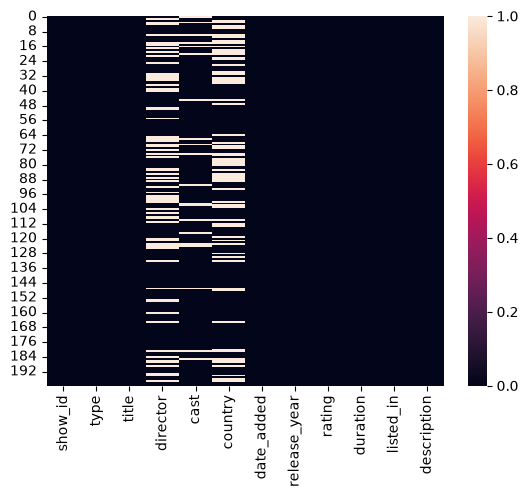

In [6]:
# CHECKING & HANDLING MISSING VALUES 

# FINDING THE TOTAL MISSING VALUE COLUMNS

print(df.isnull().sum())

# FINDING THE TOTAL MISSING VALUE COLUMNS IN %TAGE

print("% OF MISSING VALUES:")

print(df.isnull().sum() / len(df)*100)

# PLOTING THE MISSING VALUES IN HEAT MAP

sns.heatmap(df.isnull())
plt.show()


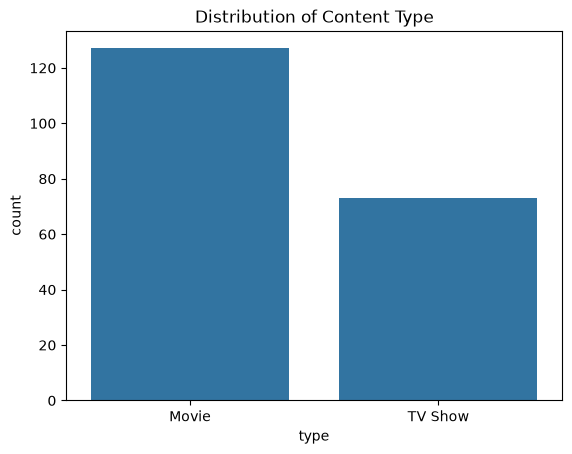

In [14]:
sns.countplot(data=df, x='type')
plt.title('Distribution of Content Type')
plt.xlabel('type')
plt.ylabel('count')
plt.show()


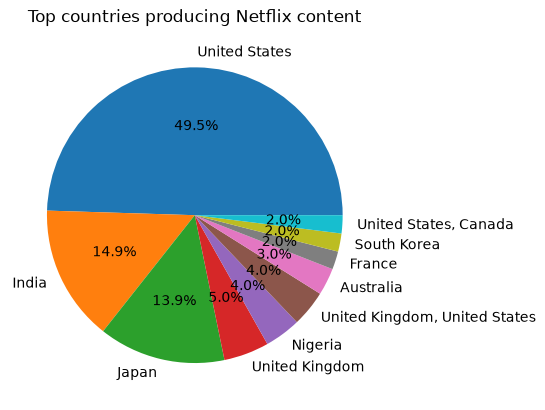

In [8]:
df['country'].value_counts().head(10).plot(kind='pie', autopct='%1.1f%%')
plt.title('Top countries producing Netflix content')
plt.show()

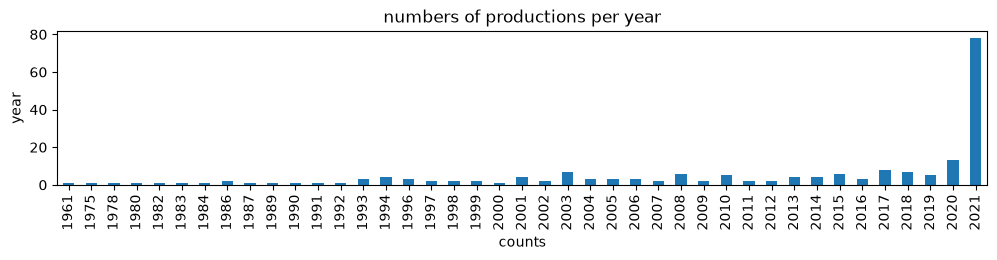

In [10]:
plt.figure(figsize=(12,2))
df['release_year'].value_counts().sort_index().plot(kind='bar')
plt.title('numbers of productions per year')
plt.xlabel('counts')
plt.ylabel('year')
plt.show()

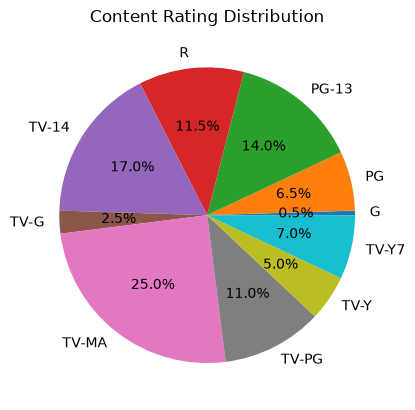

In [19]:
df['rating'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%')
plt.title('Content Rating Distribution')
plt.show()

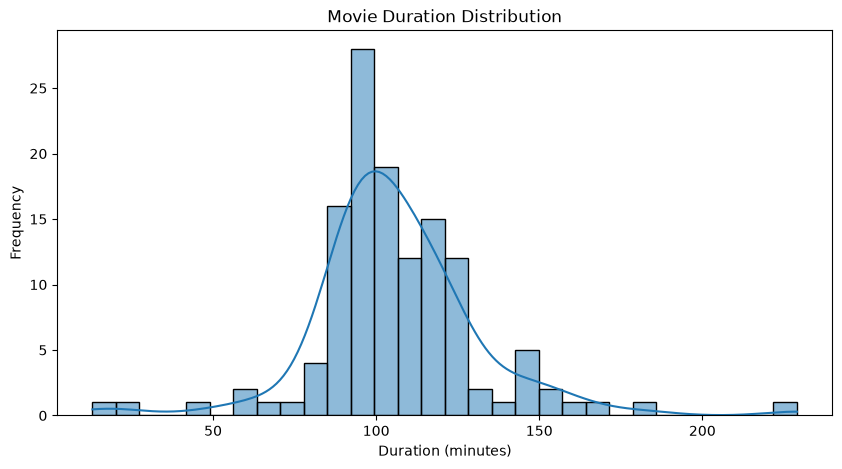

In [11]:
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_int'] = movies_df['duration'].str.extract('(\\d+)').astype(float)

plt.figure(figsize=(10,5))
sns.histplot(movies_df['duration_int'], bins=30, kde=True)
plt.title('Movie Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

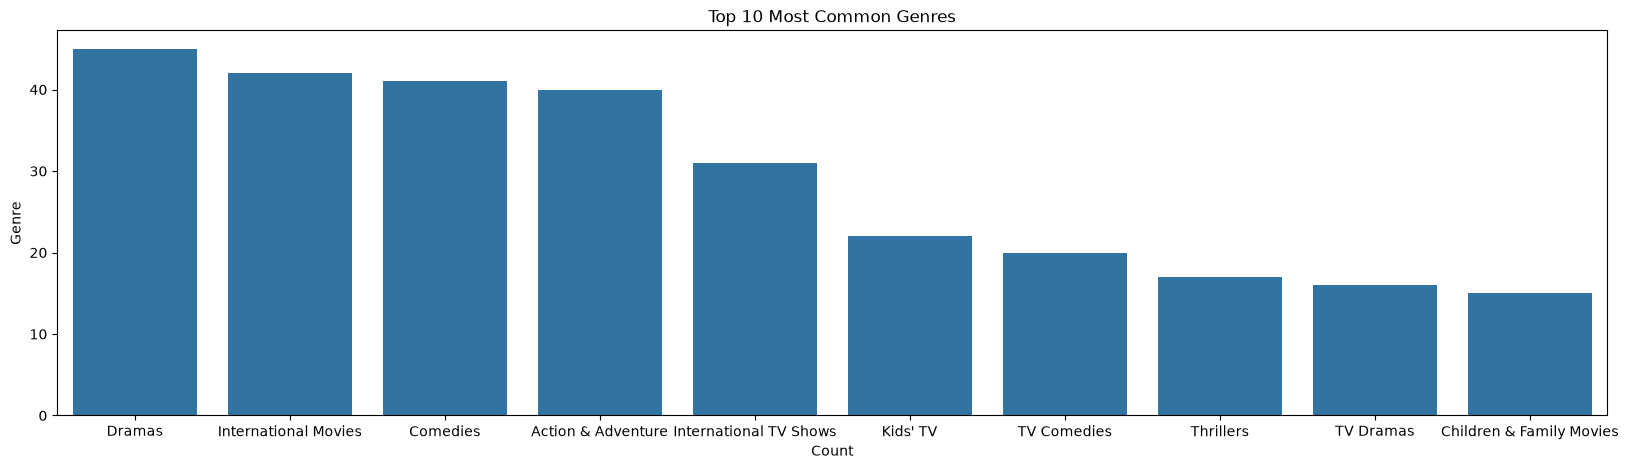

In [13]:
from collections import Counter
all_genres =','.join(df['listed_in'].dropna()).split(',')
genre_count = Counter([genre.strip() for genre in all_genres])
top_genres = genre_count.most_common(10)
label,value = zip(*top_genres)
plt.figure(figsize=(20,5))
sns.barplot(x=list(label), y=list(value))
plt.title('Top 10 Most Common Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

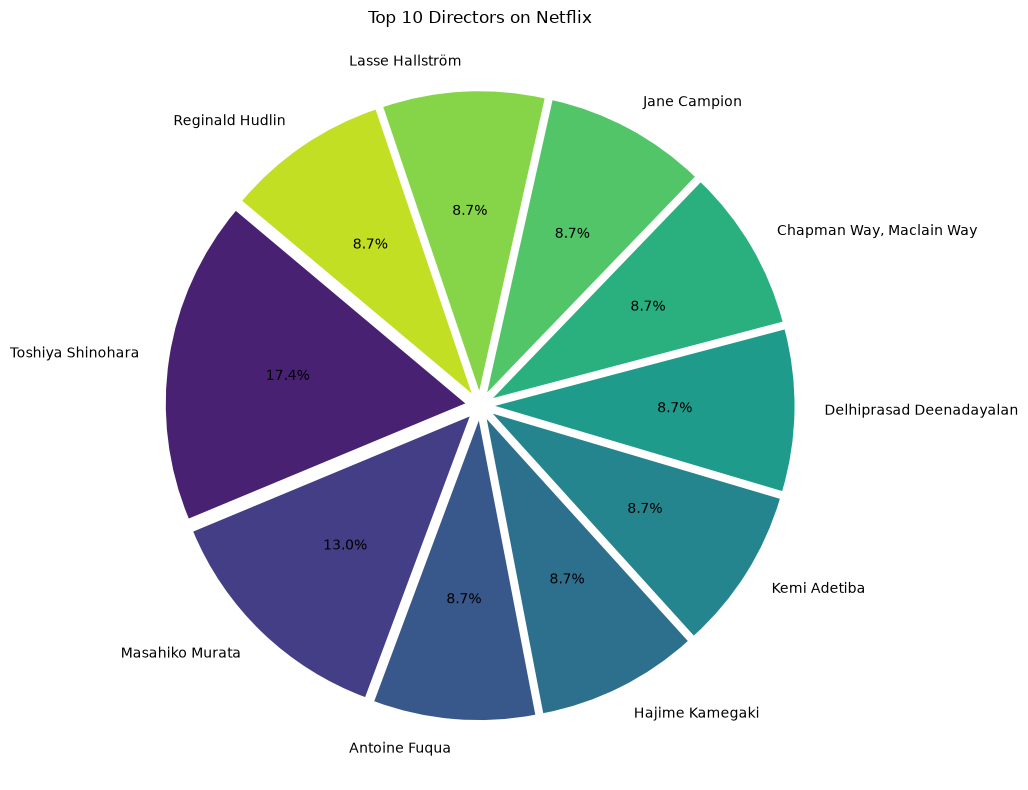

In [20]:
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)

# Create an explode array to slightly pull out all slices (e.g., 0.05 spacing)
explode = [0.05] * len(top_directors)

plt.figure(figsize=(10, 8))
plt.pie(
    top_directors.values,
    labels=top_directors.index,
    explode=explode,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('viridis', len(top_directors)),
)
plt.title('Top 10 Directors on Netflix')
plt.tight_layout()
plt.show()